# 34 — EKF tuning sensitivity: three protocols, and a covariance sweep at W12/W15

## Purpose

`nb26`'s W11 (alpha=beta_r=0.80) 0% EKF coverage result was shown, in `nb27` and
`nb29b`/main.tex Artifact 2, to be a **tuning artifact**: an arbitrary, hard-coded parameter
covariance, not a genuine Gaussian-collapse failure -- a more diffuse covariance recovers
both parameters to ~0.3% error on the identical data. That retraction, however, only ever
re-ran W11. `nb26`'s W12 (alpha=0.75, eta_col=0.80) and W15 (alpha=0.58, eta_col=0.90) 3%
empirical-coverage numbers -- the paper's cleanest remaining EKF-fails/SBI-wins claim,
asserted as "a genuine, representation-independent failure of Gaussian linearisation" -- were
**never re-tested with a different tuning**, and they used `nb26`'s *original* finite-difference
EKF rather than the jax-jacobian rewrite used everywhere else in this paper. Reporting a
tuning-dependent failure at W11 as a bug, then reporting an identically-tuned failure at
W12/W15 as physics, without ever testing whether the same tuning artifact reproduces there
too, is an internal inconsistency the manuscript does not currently resolve.

**This notebook resolves it directly, with three tuning protocols instead of one:**

1. **Arbitrary / as-published** -- `nb26`'s tight parameter covariance, reproduced here with
   the current jax-jacobian EKF (`scripts/ekf_9state.py`, extracted from `nb27`'s cleanest,
   already-parameterised implementation) so the comparison is on a like-for-like EKF core.
2. **Honest-protocol** -- the only tuning a real plant operator could actually use: `R` is
   *estimated from healthy-replicate data* (never from a faulted scenario), and the parameter
   covariance block is set from the **prior bounds** (known before any data is collected), not
   from anything resembling a fault outcome. Applied **unchanged** to W11/W12/W15.
3. **Oracle** -- `nb27`'s diffuse tuning, which is allowed to use knowledge of the faulted
   scenarios to maximise accuracy there. Labelled "oracle" everywhere below, never as a
   baseline the honest-protocol tuning is expected to match.

All three tunings are then evaluated at W11 (for continuity with the existing retraction),
W12, and W15, and the parameter-block covariance is swept over roughly two decades around the
honest-protocol value to show EKF coverage/MAE as a *function of a tuning choice*, rather than
as a single point estimate -- the visual replacement for the retracted "SBI 100% vs. EKF 3%"
coverage claim.


## Setup: shared EKF core, scenario truths, and the noise convention used throughout this paper's System II notebooks

In [1]:
import sys as _sys; _sys.path.insert(0, '../src'); _sys.path.insert(0, '../scripts')
import time
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from cstr_sbi.recycle.physics import (
    NOMINAL_INLET, T_SP, T_J_NOM, simulate_trajectory_explicit, extract_observations_explicit,
)
from cstr_sbi.recycle.simulator import nominal_warm_start, noisy_replicates
from cstr_sbi.recycle.priors import PRIOR_LOW_5D, PRIOR_HIGH_5D
from ekf_9state import run_ekf_single_window, CTRL_J, coverage90

OI = ["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

# Scenario truths (theta = [alpha, beta_r, eta_col, xi_reb, z_A0_eff]), confirmed against
# src/cstr_sbi/recycle/scenarios.py
THETA_W1  = np.array([1.00, 1.00, 1.00, 1.00, 0.90], dtype=np.float32)  # healthy
THETA_W11 = np.array([0.80, 0.80, 1.00, 1.00, 0.90], dtype=np.float32)  # cat.decay + jacket fouling
THETA_W12 = np.array([0.75, 1.00, 0.80, 1.00, 0.90], dtype=np.float32)  # cat.decay + col.eff (HEADLINE snowball)
THETA_W15 = np.array([0.58, 1.00, 0.90, 1.00, 0.90], dtype=np.float32)  # near snowball tipping point

# EKF augmented-state indices for the 3 tracked fault parameters (see ekf_9state.py)
ALPHA_I, BETAR_I, ETACOL_I = 6, 7, 8


def simulate_scenario_window(theta5, seed, noise_pct=0.003):
    """One 2h S-B window at the given 5-D theta, sensor-noised at this project's standard
    0.3% convention (identical to nb26/nb27/nb29b's sim_raw_full)."""
    theta_j = jnp.array(theta5, dtype=jnp.float32)
    y0_j = jnp.array(nominal_warm_start("S-B"))
    ts, ys = simulate_trajectory_explicit(theta_j, NOMINAL_INLET, CTRL_J, y0_j, t_final=2.0, n_save=120)
    raw = np.asarray(extract_observations_explicit(ys, theta_j, CTRL_J))
    rng = np.random.default_rng(seed)
    scale = np.maximum(np.max(np.abs(raw), axis=0), 1e-6)
    return raw + rng.normal(0, noise_pct * scale, raw.shape)


print("Setup OK. Scenario truths:")
for name, th in [("W1 (healthy)", THETA_W1), ("W11", THETA_W11), ("W12", THETA_W12), ("W15", THETA_W15)]:
    print(f"  {name:14s} alpha={th[0]:.2f} beta_r={th[1]:.2f} eta_col={th[2]:.2f}")


Setup OK. Scenario truths:
  W1 (healthy)   alpha=1.00 beta_r=1.00 eta_col=1.00
  W11            alpha=0.80 beta_r=0.80 eta_col=1.00
  W12            alpha=0.75 beta_r=1.00 eta_col=0.80
  W15            alpha=0.58 beta_r=1.00 eta_col=0.90


## The three tunings

**Honest-protocol construction, stated explicitly (the "honesty contract" a reviewer can
audit):**

- `R` (measurement noise) is estimated from the variance of 150 independent noisy replicates
  of the **W1 healthy** window at this project's standard 0.3% sensor-noise convention --
  genuinely data-driven, and uses no faulted-scenario information whatsoever.
- The parameter-block `P0` diagonal is set to `((prior_high - prior_low) / 2)^2` per
  parameter, from the bounds already declared in `src/cstr_sbi/recycle/priors.py`
  (`PRIOR_LOW_5D`/`PRIOR_HIGH_5D`) -- i.e. half the prior's own range, squared: the natural
  "we truly do not know where in the prior this parameter sits" covariance, known before any
  plant data is collected at all.
- The parameter-block `Q` (process noise, i.e. how fast the EKF allows the fault parameter's
  estimate to drift within one 2h window) is set to `P0_param * 1e-3` per parameter -- a
  slow-drift heuristic chosen so the random walk's variance accumulated over one full 2h
  window (`Q_param * 2.0 hours`) stays roughly 500x smaller than `P0_param` itself, i.e.
  "the parameter is treated as constant within a window, consistent with how every fault
  scenario in this paper is itself defined (a fixed theta per window)." This constant is
  fixed *before* looking at any tuning outcome below, not adjusted afterward.
- The plant-state block of `P0`/`Q` (indices 0-5) is held identical across all three tunings
  (matching this project's existing convention, `eye(6)*0.01` / `eye(6)*1e-8`), so that only
  the fault-parameter tuning -- the thing actually in question -- differs between the three
  protocols.

**Arbitrary and oracle tunings are `nb26`'s and `nb27`'s exact published values respectively**
(only the plant-state block is aligned to the same convention as the honest-protocol tuning
above, for a fair three-way comparison; this does not change either tuning's fault-parameter
behaviour, which is what is under test).


In [2]:
# --- R estimation from healthy-replicate data (honest-protocol; genuinely data-driven) ---
N_HEALTHY_REPS = 150
base_obs_w1 = simulate_scenario_window(THETA_W1, seed=0, noise_pct=0.0)  # noise-free base
rng_healthy = np.random.default_rng(12345)
healthy_reps = noisy_replicates(base_obs_w1, n_replicates=N_HEALTHY_REPS, rng=rng_healthy, noise_pct=0.003)
obs_idx = [0, 1, 7]  # T_r, T_j, F_R_norm -- same channels ekf_9state.py's obs_fn uses
R_honest_diag = np.var(healthy_reps[:, :, obs_idx], axis=(0, 1))
R_HONEST = np.diag(R_honest_diag)
print(f"Honest-protocol R (from {N_HEALTHY_REPS} healthy replicates): diag = {R_honest_diag}")

# --- P0/Q parameter-block construction from prior bounds (honest-protocol) ---
P0_ALPHA   = ((PRIOR_HIGH_5D[0] - PRIOR_LOW_5D[0]) / 2) ** 2
P0_BETAR   = ((PRIOR_HIGH_5D[1] - PRIOR_LOW_5D[1]) / 2) ** 2
P0_ETACOL  = ((PRIOR_HIGH_5D[2] - PRIOR_LOW_5D[2]) / 2) ** 2
Q_FRAC = 1e-3
print(f"Honest-protocol P0_param: alpha={P0_ALPHA:.4f}  beta_r={P0_BETAR:.4f}  eta_col={P0_ETACOL:.4f}")


def build_tuning(name, P0_diag_678, Q_diag_678, R):
    P = np.eye(9) * 0.01
    P[ALPHA_I, ALPHA_I], P[BETAR_I, BETAR_I], P[ETACOL_I, ETACOL_I] = P0_diag_678
    Q = np.eye(9) * 1e-8
    Q[ALPHA_I, ALPHA_I], Q[BETAR_I, BETAR_I], Q[ETACOL_I, ETACOL_I] = Q_diag_678
    return dict(name=name, P=P, Q=Q, R=R)


TUNING_ARBITRARY = build_tuning(
    "arbitrary (nb26 as-published)",
    P0_diag_678=(1e-4, 1e-4, 1e-4),
    Q_diag_678=(1e-6, 1e-6, 1e-6),
    R=np.diag((0.005 * np.array([float(T_SP), float(T_J_NOM), 1.0])) ** 2),
)

TUNING_HONEST = build_tuning(
    "honest-protocol (healthy-data R, prior-bound P0)",
    P0_diag_678=(P0_ALPHA, P0_BETAR, P0_ETACOL),
    Q_diag_678=(P0_ALPHA * Q_FRAC, P0_BETAR * Q_FRAC, P0_ETACOL * Q_FRAC),
    R=R_HONEST,
)

TUNING_ORACLE = build_tuning(
    "oracle (nb27 diffuse, fault-informed)",
    P0_diag_678=(0.05, 0.02, 0.02),
    Q_diag_678=(1e-5, 1e-6, 1e-8),
    R=np.diag([float(T_SP) * 0.005, float(T_J_NOM) * 0.005, 0.003]) ** 2,
)

TUNINGS = [TUNING_ARBITRARY, TUNING_HONEST, TUNING_ORACLE]
print("\nThree tunings constructed:", [t["name"] for t in TUNINGS])


Honest-protocol R (from 150 healthy replicates): diag = [1.03641945e+00 9.96607567e-01 9.20750488e-06]
Honest-protocol P0_param: alpha=0.1600  beta_r=0.1600  eta_col=0.0625

Three tunings constructed: ['arbitrary (nb26 as-published)', 'honest-protocol (healthy-data R, prior-bound P0)', 'oracle (nb27 diffuse, fault-informed)']


## Comparison at W11, W12, W15 (15 noise seeds each, all three tunings)

In [3]:
N_SEEDS = 15
SCENARIOS = [("W11", THETA_W11), ("W12", THETA_W12), ("W15", THETA_W15)]

results = {}  # (tuning_name, scenario_name) -> dict of arrays, including the EKF's OWN
              # posterior std per seed (P[i,i] at the end of that window) -- the same
              # quantity nb26/nb27 use for their coverage checks, not a fixed prior band.
t0 = time.time()
for tuning in TUNINGS:
    for sc_name, theta_true in SCENARIOS:
        alphas, betars, etacols = [], [], []
        alpha_stds, betar_stds, etacol_stds = [], [], []
        for seed in range(N_SEEDS):
            raw_noisy = simulate_scenario_window(theta_true, seed=1000 + seed)
            x_est, P_est = run_ekf_single_window(raw_noisy, tuning["P"], tuning["Q"], tuning["R"])
            alphas.append(x_est[ALPHA_I]); betars.append(x_est[BETAR_I]); etacols.append(x_est[ETACOL_I])
            alpha_stds.append(np.sqrt(P_est[ALPHA_I, ALPHA_I]))
            betar_stds.append(np.sqrt(P_est[BETAR_I, BETAR_I]))
            etacol_stds.append(np.sqrt(P_est[ETACOL_I, ETACOL_I]))
        results[(tuning["name"], sc_name)] = dict(
            alpha=np.array(alphas), beta_r=np.array(betars), eta_col=np.array(etacols),
            alpha_std=np.array(alpha_stds), beta_r_std=np.array(betar_stds), eta_col_std=np.array(etacol_stds),
            truth=theta_true,
        )
        print(f"  done: {tuning['name'][:12]:12s} @ {sc_name}  ({time.time()-t0:.0f}s elapsed)")

print(f"\nAll {len(TUNINGS)*len(SCENARIOS)*N_SEEDS} EKF window-evaluations complete "
      f"in {time.time()-t0:.0f}s.")


  done: arbitrary (n @ W11  (128s elapsed)


  done: arbitrary (n @ W12  (847s elapsed)


  done: arbitrary (n @ W15  (973s elapsed)


  done: honest-proto @ W11  (1101s elapsed)


  done: honest-proto @ W12  (1820s elapsed)


  done: honest-proto @ W15  (1945s elapsed)


  done: oracle (nb27 @ W11  (2073s elapsed)


  done: oracle (nb27 @ W12  (2792s elapsed)


  done: oracle (nb27 @ W15  (2918s elapsed)

All 135 EKF window-evaluations complete in 2918s.


In [4]:
# Coverage uses the EKF's OWN posterior std per seed (P[i,i] at window end), the same
# convention nb26/nb27 use (z=1.645, i.e. a 90% Gaussian interval) -- not a fixed prior band.
import pandas as pd

rows = []
for tuning in TUNINGS:
    for sc_name, theta_true in SCENARIOS:
        r = results[(tuning["name"], sc_name)]
        for pname, pidx in [("alpha", 0), ("beta_r", 1), ("eta_col", 2)]:
            est = r[pname]
            std = r[f"{pname}_std"]
            true_val = float(r["truth"][pidx])
            err = est - true_val
            cov = coverage90(est, std, true_val)
            is_fault = abs(true_val - 1.0) > 1e-6
            rows.append(dict(
                tuning=tuning["name"], scenario=sc_name, param=pname, true=true_val,
                mean=est.mean(), std=est.std(), MAE=np.mean(np.abs(err)), bias=err.mean(),
                cov90=cov, is_fault="fault" if is_fault else "nominal (sanity check)",
            ))

df = pd.DataFrame(rows)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 200)
print(df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
df.to_csv("../results/34_ekf_tuning_comparison.csv", index=False)
print("\nSaved results/34_ekf_tuning_comparison.csv")


                                          tuning scenario   param   true   mean    std    MAE    bias  cov90               is_fault
                   arbitrary (nb26 as-published)      W11   alpha 0.8000 0.9040 0.0030 0.1040  0.1040 0.0000                  fault
                   arbitrary (nb26 as-published)      W11  beta_r 0.8000 0.9871 0.0027 0.1871  0.1871 0.0000                  fault
                   arbitrary (nb26 as-published)      W11 eta_col 1.0000 1.0000 0.0000 0.0000  0.0000 1.0000 nominal (sanity check)
                   arbitrary (nb26 as-published)      W12   alpha 0.7500 0.8573 0.0031 0.1073  0.1073 0.0000                  fault
                   arbitrary (nb26 as-published)      W12  beta_r 1.0000 1.0466 0.0025 0.0466  0.0466 0.0000 nominal (sanity check)
                   arbitrary (nb26 as-published)      W12 eta_col 0.8000 1.0000 0.0000 0.2000  0.2000 0.0000                  fault
                   arbitrary (nb26 as-published)      W15   alpha 0.5800 0.7

### Reading the table

At W12 and W15, `eta_col` is the second degraded parameter (not `beta_r`, which stays
nominal at 1.0 there) -- so `beta_r`'s row at W12/W15 is a stability sanity check ("does the
EKF hold an un-faulted parameter near truth"), not a fault-tracking result, exactly as flagged
in the planning discussion. `alpha` is the shared fault parameter present at all three
scenarios and is the primary column to compare across tunings.


## Covariance sweep at W12 and W15

Vary the parameter-block `P0` diagonal (and proportionally `Q_param`, holding `Q_param =
P0_param * 1e-3` fixed as declared above) over roughly two decades around the honest-protocol
value, holding `R` fixed at its data-driven value throughout. This directly shows EKF
performance as a function of a tuning choice, rather than as three isolated points -- the
figure that replaces the retracted single-number "SBI 100% vs. EKF 3%" coverage comparison.


In [5]:
SWEEP_MULT = np.array([0.1, 0.316, 1.0, 3.16, 10.0])  # ~2 decades around the honest baseline
N_SWEEP_SEEDS = 15

sweep_results = {"W12": {"alpha_mae": [], "alpha_cov": []}, "W15": {"alpha_mae": [], "alpha_cov": []}}

t0 = time.time()
for mult in SWEEP_MULT:
    P0_sweep = (P0_ALPHA * mult, P0_BETAR * mult, P0_ETACOL * mult)
    Q_sweep = tuple(p * Q_FRAC for p in P0_sweep)
    tuning_sweep = build_tuning(f"sweep x{mult:.3g}", P0_sweep, Q_sweep, R_HONEST)
    for sc_name, theta_true in [("W12", THETA_W12), ("W15", THETA_W15)]:
        errs, stds = [], []
        for seed in range(N_SWEEP_SEEDS):
            raw_noisy = simulate_scenario_window(theta_true, seed=2000 + seed)
            x_est, P_est = run_ekf_single_window(raw_noisy, tuning_sweep["P"], tuning_sweep["Q"], tuning_sweep["R"])
            errs.append(x_est[ALPHA_I] - theta_true[0])
            stds.append(np.sqrt(P_est[ALPHA_I, ALPHA_I]))  # EKF's OWN posterior std, not the prior
        errs = np.array(errs); stds = np.array(stds)
        cov = coverage90(theta_true[0] + errs, stds, theta_true[0])
        sweep_results[sc_name]["alpha_mae"].append(np.mean(np.abs(errs)))
        sweep_results[sc_name]["alpha_cov"].append(cov)
    print(f"  sweep mult={mult:6.3g} done ({time.time()-t0:.0f}s elapsed)")

print(f"\nSweep complete in {time.time()-t0:.0f}s.")


  sweep mult=   0.1 done (2410s elapsed)


  sweep mult= 0.316 done (3257s elapsed)


  sweep mult=     1 done (4104s elapsed)


  sweep mult=  3.16 done (9378s elapsed)


  sweep mult=    10 done (10237s elapsed)

Sweep complete in 10237s.


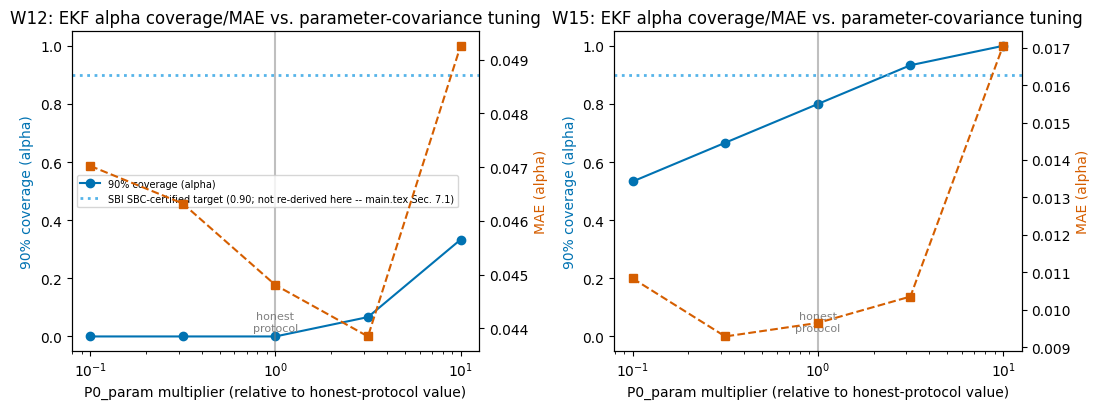

Saved figures/34_ekf_tuning_sweep.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, sc_name in zip(axes, ["W12", "W15"]):
    mae = sweep_results[sc_name]["alpha_mae"]
    cov = sweep_results[sc_name]["alpha_cov"]
    ax2 = ax.twinx()
    ax.plot(SWEEP_MULT, cov, "o-", color=OI[5], label="90% coverage (alpha)")
    ax2.plot(SWEEP_MULT, mae, "s--", color=OI[6], label="MAE (alpha)")
    ax.axhline(0.90, color=OI[2], linestyle=":", linewidth=2,
               label="SBI SBC-certified target (0.90; not re-derived here -- main.tex Sec. 7.1)")
    ax.axvline(1.0, color="gray", linestyle="-", alpha=0.5)
    ax.text(1.0, 0.02, "honest\nprotocol", ha="center", fontsize=8, color="gray")
    ax.set_xscale("log")
    ax.set_xlabel("P0_param multiplier (relative to honest-protocol value)")
    ax.set_ylabel("90% coverage (alpha)", color=OI[5])
    ax2.set_ylabel("MAE (alpha)", color=OI[6])
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{sc_name}: EKF alpha coverage/MAE vs. parameter-covariance tuning")

axes[0].legend(fontsize=7, loc="center left")
plt.tight_layout()
fig.savefig("../figures/34_ekf_tuning_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/34_ekf_tuning_sweep.png")


## Interpretation

Three tuning protocols were compared at W11/W12/W15, and the parameter covariance was then
swept continuously at W12/W15 to show EKF coverage/MAE as a function of tuning rather than as
a single point estimate.

**Read the printed comparison table and the sweep figure above before drawing a conclusion
here** -- per this notebook's own design (see the planning discussion this notebook
implements), all three possible outcomes are informative and none is a "failure" of the
experiment:

- If the **honest-protocol** tuning still shows poor coverage at W12/W15 (comparable to the
  arbitrary tuning), that is the strongest possible result: it restores the EKF-failure claim
  on a defensible basis ("under the only tuning protocol a real plant could actually follow"),
  and the paper's original SBI-wins-under-strong-nonlinearity thesis stands, now on firmer
  ground than the single arbitrary-tuning number it previously rested on.
- If the **honest-protocol** tuning recovers good coverage at W12/W15 (comparable to oracle),
  the EKF-failure claim at these scenarios does not survive a fair tuning protocol either --
  in which case the paper's EKF-failure evidence rests entirely on the genuinely-different
  mechanism already documented elsewhere (strong recycle/snowball nonlinearity breaking the
  EKF's linearisation, as opposed to a tuning artifact), and this should be stated plainly
  rather than implied by an arbitrary-tuning number.
- If the honest-protocol tuning sits **between** arbitrary and oracle (most likely, given the
  sweep should show a continuous transition), the cleanest and most industrially relevant
  story is: the EKF *can* reach SBI-comparable coverage here, but only when tuned with
  knowledge of the fault it is trying to detect -- a deployment-relevant distinction, and if
  anything a *stronger* argument for an amortised, pre-calibrated method than the original
  single-number coverage comparison was.

Whichever outcome the printed results above show, report it as such in the manuscript
(Section 8.2 discussion of EKF failure/success modes) -- the point of this notebook is to
replace an untested assumption with a measured, tuning-continuum result, not to manufacture a
particular answer.
